<a href="https://colab.research.google.com/github/alwicareer-sketch/Waiter-Tips-Prediction-with-Machine-Learning/blob/main/Waiter_Tips_Prediction_with_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Waiter Tips Prediction

Dataset berisi data:
1. total_bill : total tagihan dalam dollar sudah termasuk pajak (X1)
2. tip : pemberian tip kepada pelayan dalam bentuk dollar (Y)
3. sex : jenis kelamin (X2)
4. smoker : orang-orang perokok atau tidak (X3)
5. day : hari (X4)
6. time : waktu (lunch atau dinner) (X5)
7. size : jumlah orang di table (X6)

In [229]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [230]:
data = pd.read_csv("tips.csv")
print(data.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


# Exploratory Data Analysis

In [231]:
print('Shape dataset:', data.shape)
print('\nInformasi dataset:')
print(data.info())
print('\nStatistik deskriptif:\n', data.describe())

Shape dataset: (244, 7)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None

Statistik deskriptif:
        total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [232]:
figure = px.scatter(data_frame = data, x="total_bill",
                    y="tip", size="size", color= "day", trendline="ols")
figure.show()

In [233]:
figure = px.scatter(data_frame = data, x="total_bill",
                    y="tip", size="size", color= "sex", trendline="ols")
figure.show()

In [234]:
figure = px.scatter(data_frame = data, x="total_bill",
                    y="tip", size="size", color= "time", trendline="ols")
figure.show()

In [235]:
figure = px.pie(data,
             values='tip',
             names='day',hole = 0.5)
figure.show()

In [236]:
figure = px.pie(data,
             values='tip',
             names='sex',hole = 0.5)
figure.show()

In [237]:
figure = px.pie(data,
             values='tip',
             names='smoker',hole = 0.5)
figure.show()

In [238]:
figure = px.pie(data,
             values='tip',
             names='time',hole = 0.5)
figure.show()

In [239]:
from sklearn.preprocessing import MinMaxScaler

#Define MinMaxScaler as scaler
scaler = MinMaxScaler()
#list all the feature that need to be scaled
scaling_column = ['total_bill', 'size']
#Apply fit_transfrom to scale selected feature
data[scaling_column] = scaler.fit_transform(data[scaling_column])
#Cheking min and max value of the scaling_column
print(data[scaling_column].describe().T[['min','max']])
print('')

# Convert feature/column 'sex'
LE = LabelEncoder()
data['sex'] = LE.fit_transform(data['sex'])
print(LE.classes_)
print(np.sort(data['sex'].unique()))
print('')

# Convert feature/column 'smoker'
LE = LabelEncoder()
data['smoker'] = LE.fit_transform(data['smoker'])
print(LE.classes_)
print(np.sort(data['smoker'].unique()))
print('')

# Convert feature/column 'day'
LE = LabelEncoder()
data['day'] = LE.fit_transform(data['day'])
print(LE.classes_)
print(np.sort(data['day'].unique()))
print('')

# Convert feature/column 'time'
LE = LabelEncoder()
data['time'] = LE.fit_transform(data['time'])
print(LE.classes_)
print(np.sort(data['time'].unique()))

# Definisi X dan y
X = data.drop('tip', axis=1)
y = data['tip']


            min  max
total_bill  0.0  1.0
size        0.0  1.0

['Female' 'Male']
[0 1]

['No' 'Yes']
[0 1]

['Fri' 'Sat' 'Sun' 'Thur']
[0 1 2 3]

['Dinner' 'Lunch']
[0 1]


<Figure size 640x480 with 0 Axes>

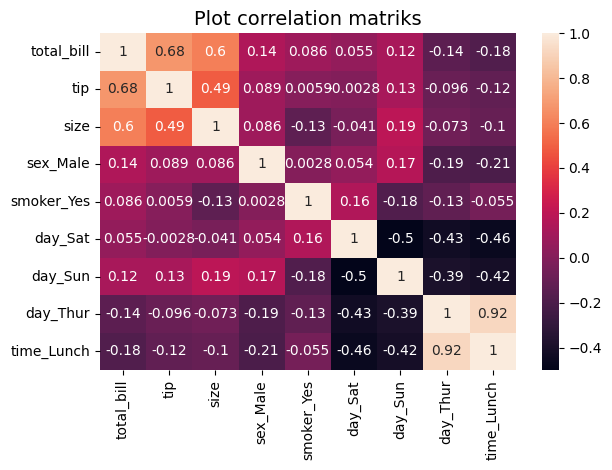

In [240]:
plt.clf()
# mengatur ukuran gambar/plot
plt.rcParams['figure.dpi'] = 100
plt.figure()
sns.heatmap(data_encoded.corr(), annot=True)
plt.title('Plot correlation matriks', size=14)
plt.tight_layout()
plt.show()

In [241]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y,
                                                test_size=0.2,
                                                random_state=42)

# Membuat Model Regresi

In [242]:
from sklearn.linear_model import LinearRegression
# Call the regressor
reg = LinearRegression()
# Fit the regressor to the training data
reg = reg.fit(xtrain, ytrain)
print('Coefficient : ' + str(reg.coef_))
print('Intercept : ' + str(reg.intercept_))
# Apply the regressor/model to the test data
y_pred = reg.predict(xtest)
print('\nyPredicted Value : ' + str(y_pred))

Coefficient : [ 4.48587142  0.03271041 -0.19174368 -0.00682977  0.06122632  1.20151631]
Intercept : 1.1456607286919902

yPredicted Value : [2.98575218 1.94061325 3.90398163 3.84498032 2.1680261  2.60582699
 3.65155039 2.31090817 2.50534068 2.3509249  2.83515653 2.13537228
 2.1389529  2.2854076  1.84415015 3.13003355 2.9775778  3.14430016
 2.63638097 5.76225288 3.51539752 3.30404608 2.24355298 2.02073543
 3.09625338 2.26938652 2.0815602  3.27434496 3.14662672 6.60403271
 4.93408016 1.65891577 3.2774898  2.83817187 2.91871607 3.8815044
 2.0688538  5.47790762 2.37480412 3.06180769 2.11094147 2.50259602
 3.36699633 2.29479093 1.95079059 0.94708728 1.89400456 3.11987541
 1.8813126 ]


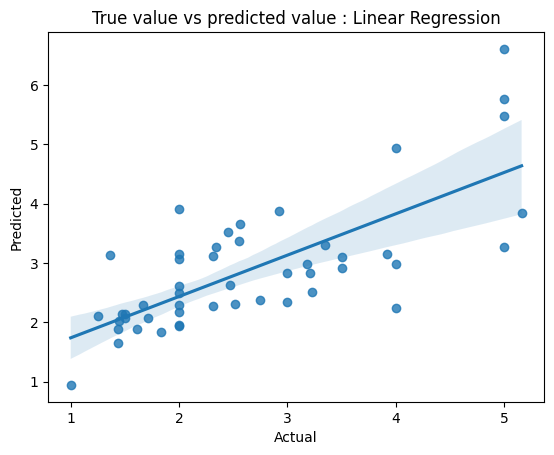

In [243]:
#Plotting y_test dan y_pred
sns.regplot(x = ytest, y = y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('True value vs predicted value : Linear Regression')
plt.show()

In [244]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Menghitung MSE
mse = mean_squared_error(ytest, y_pred)
print('Mean squared error (MSE):', mse)
# Menghitung MAE
mae = mean_absolute_error(ytest, y_pred)
print('Mean absolute error (MAE):', mae)
# Menghitung MAPE
mape = np.mean(np.abs((ytest - y_pred) / ytest)) * 100
print('Mean absolute percentage error (MAPE):', mape)
# Menghitung RMSE
rmse = np.sqrt(mse)
print('Root Mean Squared Error (RMSE):', rmse)
# Menghitung Koefisien Determinasi (R^2)
r2 = r2_score(ytest, y_pred)
print('Koefisien Determinasi (R^2):', r2)

Mean squared error (MSE): 0.6948129686287681
Mean absolute error (MAE): 0.6703807496461146
Mean absolute percentage error (MAPE): 27.85561522090238
Root Mean Squared Error (RMSE): 0.8335544185167325
Koefisien Determinasi (R^2): 0.4441368826121955


# Uji Asumsi Klasik

In [245]:
# Residual
residual = ytest - y_pred

# Nilai prediksi
fitted_values = y_pred

In [246]:
from scipy.stats import shapiro

stat, p_value = shapiro(residual)

print("Shapiro-Wilk Statistic:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("Residual berdistribusi normal")
else:
    print("Residual tidak berdistribusi normal")


Shapiro-Wilk Statistic: 0.9769514093855113
p-value: 0.44516793240259017
Residual berdistribusi normal


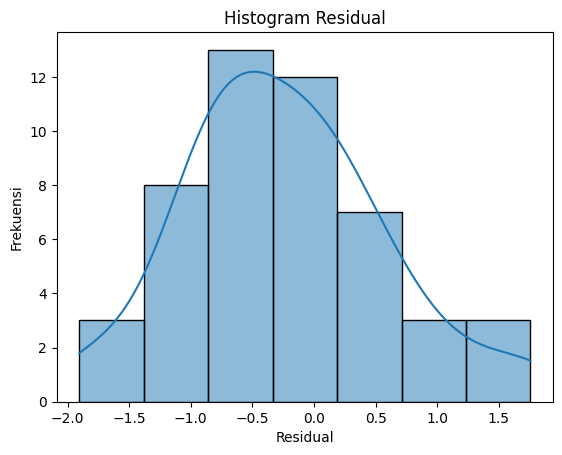

In [247]:
plt.figure()
sns.histplot(residual, kde=True)
plt.title("Histogram Residual")
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.show()

In [248]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = xtrain.copy()

X_vif = X_vif.assign(constant=1)

vif_data = pd.DataFrame()
vif_data["Variabel"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

     Variabel        VIF
0  total_bill   1.612597
1         sex   1.049937
2      smoker   1.176656
3         day   1.758183
4        time   1.726083
5        size   1.554511
6    constant  12.191164


In [249]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_bp = sm.add_constant(xtrain)
model_bp = sm.OLS(ytrain, X_bp).fit()

bp_test = het_breuschpagan(model_bp.resid, X_bp)
print("Breusch–Pagan Test Results:")
print("LM Statistic      :", bp_test[0])
print("LM p-value        :", bp_test[1])
print("F Statistic       :", bp_test[2])
print("F p-value         :", bp_test[3])

Breusch–Pagan Test Results:
LM Statistic      : 45.813922690472644
LM p-value        : 3.224118926858484e-08
F Statistic       : 9.622231087890318
F p-value         : 3.1465719265247797e-09


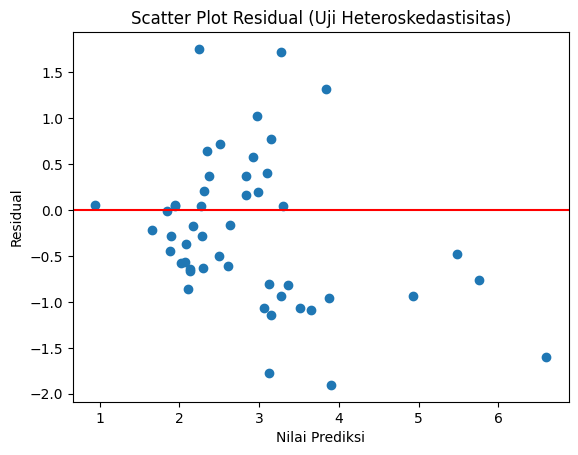

In [250]:
plt.figure()
plt.scatter(fitted_values, residual)
plt.axhline(0, color='red')
plt.xlabel("Nilai Prediksi")
plt.ylabel("Residual")
plt.title("Scatter Plot Residual (Uji Heteroskedastisitas)")
plt.show()

In [251]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residual)
print("Nilai Durbin-Watson:", dw)

Nilai Durbin-Watson: 1.9316612018597668


# Uji Signifikansi Simultan (Uji F) dan Parsial (Uji T)

In [252]:
import statsmodels.api as sm

# Tambahkan konstanta (intercept)
X_ols = sm.add_constant(X)

# Model OLS
model_ols = sm.OLS(y, X_ols).fit()

# Ringkasan model (opsional)
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     34.86
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           4.50e-30
Time:                        13:10:59   Log-Likelihood:                -347.78
No. Observations:                 244   AIC:                             709.6
Df Residuals:                     237   BIC:                             734.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2014      0.228      5.277      0.0

In [253]:
print("Uji Signifikansi Simultan (Uji F):")
print("F-statistic :", model_ols.fvalue)
print("Prob (F-statistic) :", model_ols.f_pvalue)

Uji Signifikansi Simultan (Uji F):
F-statistic : 34.85648725776275
Prob (F-statistic) : 4.4973898200708404e-30


In [254]:
print("\nUji Signifikansi Parsial (Uji t):")

for var, coef, tval, pval in zip(
    model_ols.params.index,
    model_ols.params.values,
    model_ols.tvalues.values,
    model_ols.pvalues.values
):
    print(f"Variabel      : {var}")
    print(f"Koefisien     : {coef}")
    print(f"t-statistic   : {tval}")
    print(f"p-value       : {pval}")
    print("-" * 40)


Uji Signifikansi Parsial (Uji t):
Variabel      : const
Koefisien     : 1.2013745686944923
t-statistic   : 5.277030572421917
p-value       : 2.9626331597126207e-07
----------------------------------------
Variabel      : total_bill
Koefisien     : 4.49205537383267
t-statistic   : 9.86771505705462
p-value       : 1.8371969667207638e-19
----------------------------------------
Variabel      : sex
Koefisien     : -0.027662269634809722
t-statistic   : -0.19677029557869652
p-value       : 0.8441759311914128
----------------------------------------
Variabel      : smoker
Koefisien     : -0.0864011692055255
t-statistic   : -0.5912270844231092
p-value       : 0.5549317341596134
----------------------------------------
Variabel      : day
Koefisien     : -0.005437194272217397
t-statistic   : -0.055344831798302414
p-value       : 0.9559103736550335
----------------------------------------
Variabel      : time
Koefisien     : 0.0023380980487624214
t-statistic   : 0.01167075472397551
p-value     